In [3]:
using PyPlot
using JLD2
using Statistics
using ProgressBars

In [4]:
pathdir = "Y:/TwoDGas/2025/07/04"
@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds
N_atoms_condensate = 80000;

### Check validity of image region

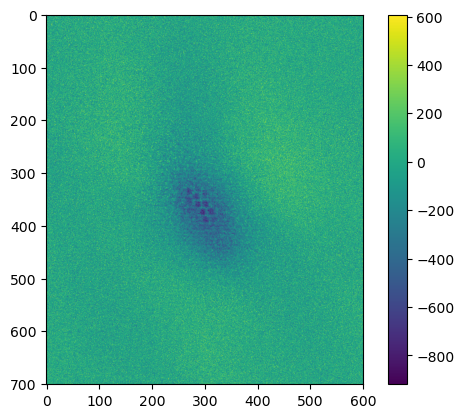

In [6]:
i, j = 1, 1

close("all")
fig, axs = subplots()

img1 = imshow(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :])
colorbar(img1)

# pygui(true); show()
pygui(false);

### Intensity integrated over the condensate

In [7]:
Iatoms_img, Ibkg_img, Idark_img = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

if length(τ_exp) == 1
    Convertion_factor = (0.85 * 0.107 * τ_exp)
end

for i = ProgressBar(1:length(Sat))
    if length(τ_exp) > 1
        Convertion_factor = (0.85 * 0.107 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        Iatoms_img[i, j] = sum(Imgs_atoms_crop_ds[i, j, :, :])
        Ibkg_img[i, j] = sum(Imgs_bkg_crop_ds[i, j, :, :])
        Idark_img[i, j] = sum(Imgs_dark_crop_ds[i, j, :, :])
        
        Iatoms_img[i, j] /= Convertion_factor
        Ibkg_img[i, j] /= Convertion_factor
        Idark_img[i, j] /= Convertion_factor
    end
end

Iatoms_img /= N_atoms_condensate
Ibkg_img /= N_atoms_condensate
Idark_img /= N_atoms_condensate;

0.0%┣                                               ┫ 0/6 [00:07<00:-45, -7s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:10<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [00:11<00:43, 11s/it]
50.0%┣████████████████████████                        ┫ 3/6 [00:12<00:17, 6s/it]
66.7%┣████████████████████████████████                ┫ 4/6 [00:13<00:08, 4s/it]
83.3%┣████████████████████████████████████████        ┫ 5/6 [00:14<00:03, 3s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:15<00:00, 3s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:15<00:00, 3s/it]


### Compute mean/std

In [9]:
Mean_atoms, Mean_bkg, Mean_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:length(Sat)
    atoms, bkg, dark = [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            push!(atoms, Iatoms_img[i, j]), push!(bkg, Ibkg_img[i, j]), push!(dark, Idark_img[i, j])
        end
    end
    Mean_atoms[i], Mean_bkg[i], Mean_dark[i] = mean(atoms), mean(bkg), mean(dark)
    Std_atoms[i], Std_bkg[i], Std_dark[i] = std(atoms), std(bkg), std(dark)
end

## Plots

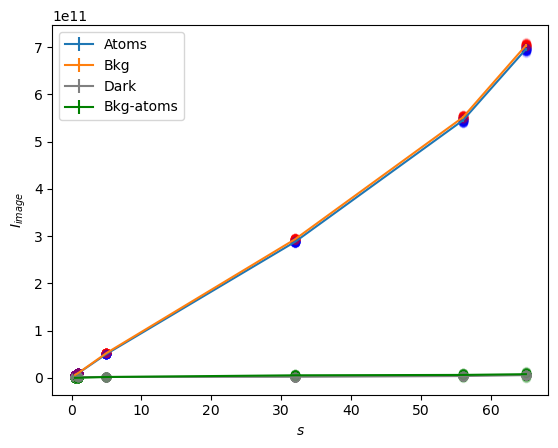

In [10]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_img[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_img[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_img[i, j], color="grey")
        scatter(Sat[i], Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

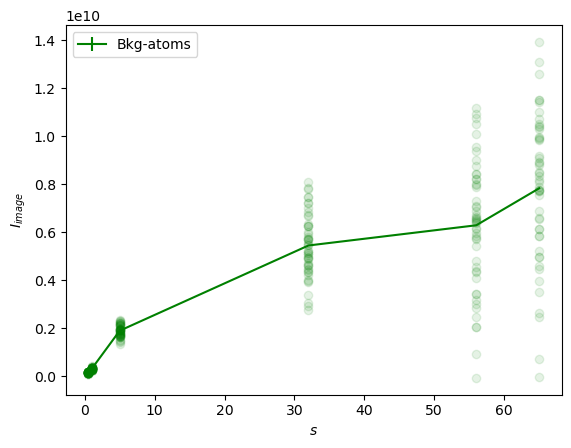

In [11]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Ibkg_img[i, j]-Iatoms_img[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);

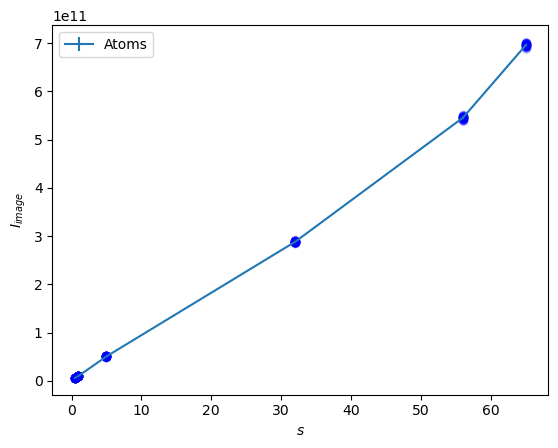

In [12]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_img[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{image}")

legend()

# pygui(true); show();
pygui(false);